# Contexto: 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhonattanreales21/nlp_icesi/blob/main/unidad_2/Cano_Reales_nlp_with_lstm.ipynb)

**Taller NLP con Long-Short Term Memory (LSTM) + Word Embeddings**

Integrantes:
- Andres Cano
- Jhonattan Reales

En este notebook implementaremos un clasificador de noticias (4 categorias) del dataset: ag_news en inglés utilizando la arquitectura de red LSTM.

A lo largo de este notebook exploraremos el dataset en cuestión, definiremos la arquitectura propuesta y sus implicaciones, entrenaremos y evaluaremos el modelo, por ultimo, implementaremos el modelo clasificador en un conjunto de noticias que el modelo no haya visto con anterioridad.

**Nota:** En este taller no realizaremos tuneo de hiperparametros de la arquitectura definida, el alcance llega hasta la definición y entrenamiento de 5 epocas con una configuración base pre-establecida. En futuras iteraciones incluiremos el tuneo de hiperparametros.


# **Paquetes y Semilla**

In [104]:
import pkg_resources
import warnings
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

import re
from collections import Counter

from tqdm.auto import tqdm

In [38]:
# Usar GPU si existe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

warnings.filterwarnings("ignore")

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = "google-colab" in installed_packages

SEED = 198

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Hace que operaciones CUDA sean deterministas (más reproducible, un poco más lento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fijada en:", SEED)

Device: cpu
Seed fijada en: 198


# Lectura de datos
Este es un dataset tamaño mediano de articulos de noticias en idioma inglés con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [3]:
from datasets import load_dataset

ds = load_dataset("ag_news")
print(ds)

print("\nEjemplo train[0]:")
print(ds["train"][0])

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 2223387.77 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Ejemplo train[0]:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


# EDA
Procedemos a realizar un analisis exploratorio basico de las noticias y los labels de estas, con la finalidad de hacernos una idea de las particularidades de nuestro dataset y la posible necesidad de realizar pre-procesamientos.

## Distribucion de Clases

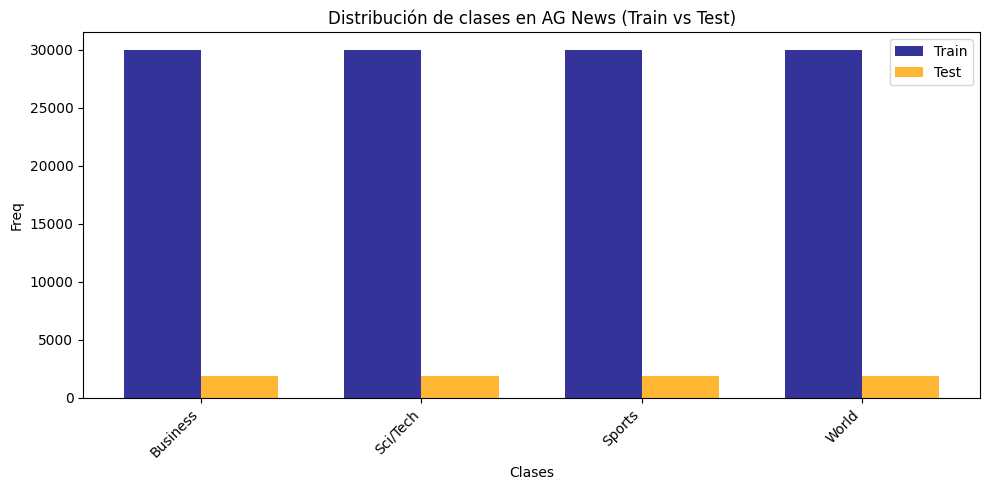

In [15]:
# Distribucion de clases en TRAIN y TEST
label_counts_train = Counter(ds["train"]["label"])
label_counts_test = Counter(ds["test"]["label"])

label_names = ds["train"].features["label"].names

# Conteo por nombre para train y test
counts_by_name_train = {label_names[k]: v for k, v in label_counts_train.items()}
counts_by_name_test = {label_names[k]: v for k, v in label_counts_test.items()}

# Preparamos datos para graficar
names = list(counts_by_name_train.keys())
counts_train = [counts_by_name_train[n] for n in names]
counts_test = [counts_by_name_test[n] for n in names]

# Graficamos la distribución de clases en train y test
x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, counts_train, width, label="Train", color="navy", alpha=0.8)
plt.bar(x + width / 2, counts_test, width, label="Test", color="orange", alpha=0.8)
plt.xlabel("Clases")
plt.ylabel("Freq")
plt.title("Distribución de clases en AG News (Train vs Test)")
plt.xticks(x, names, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Longitud de tokens por noticia

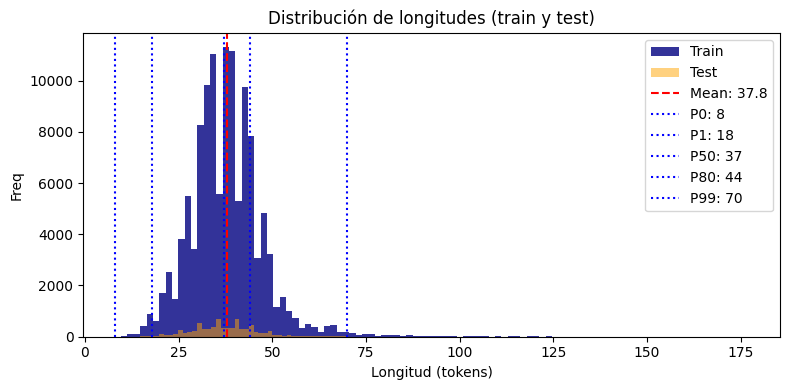

In [26]:
# Función simple de tokenización (solo para análisis de longitud, no para el modelo)
def simple_word_tokenizer(text: str):
    return text.lower().split()


# Analizamos la distribución de longitudes (en tokens) del texto
lengths_train = np.array([len(simple_word_tokenizer(t)) for t in ds["train"]["text"]])
lengths_test = np.array([len(simple_word_tokenizer(t)) for t in ds["test"]["text"]])

# Graficamos la distribución de longitudes y marcamos percentiles clave
percentiles = [0, 1, 50, 80, 99]
pvals_train = [int(np.percentile(lengths_train, p)) for p in percentiles]

plt.figure(figsize=(8, 4))
plt.hist(lengths_train, bins=100, color="navy", alpha=0.8, label="Train")
plt.hist(lengths_test, bins=100, color="orange", alpha=0.5, label="Test")
plt.axvline(
    lengths_train.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {lengths_train.mean():.1f}",
)
for p, val in zip(percentiles, pvals_train):
    plt.axvline(val, color="blue", linestyle=":", label=f"P{p}: {val}")
plt.xlabel("Longitud (tokens)")
plt.ylabel("Freq")
plt.title("Distribución de longitudes (train y test)")
plt.legend()
plt.tight_layout()
plt.show()

**Notas:**  
- Podemos observar que el dataset tanto de train como test, presentan una distribución de clases muy pareja, lo que en cierta medida disminuye la probabilidad de tener inconvenientes de desbalance a la hora de realizar la predicción de los labels de las noticias en el test set (predicción multiclase).
- Con respecto a la longitud de los tokens por documento (noticia), notamos cierta variabilidad. Existen noticias con muy pocos tokens, incluso por debajo de 20 tokens, en contraste con noticias de mas de 100 tokens.

El tema de la variabilidad en los tokens por documento, nos lleva a la necesidad de: 
- Restringir la longitud de los tokens por documento (ej: a 70 tokens).
- Hacer clipping para los documentos que excedan el limite que estableceremos.
- Utilizar padding para rellenar los tokens que nos hacen falta en algunos documentos.

# Construcción del Vocabulario

En esta sección construimos el vocabulario, que es el mecanismo que traduce el lenguaje humano en estructuras numéricas que una red neuronal puede procesar. Cada palabra única del corpus recibirá un identificador entero. Este mapeo texto-número es el primer paso para poder entrenar embeddings.  

También es necesario controlar el tamaño del vocabulario. Si incluyéramos todas las palabras distintas del corpus esto inflaría la matriz de embeddings, aumentando el consumo de memoria y el costo computacional. Debido a lo anterior, seleccionamos las 20,000 palabras mas frecuentes del conjunto total de noticias.  

Por ultimo, añadimos tokens especiales que ayudan a organizar los datos. El token [PAD] (ID = 0) sirve para completar las secuencias hasta una misma longitud, y el token [UNK] (ID = 1) representa palabras que el modelo no ha visto antes (Tokens excluidos del corpus).

In [35]:
# Para realizar la tokenización de cara a construir el vocabulario, vamos a usar una función simple que:
# 1) pasa a minúsculas
# 2) elimina puntuación y caracteres raros
# 3) divide por espacios → lista de palabras


def tokenize(text):
    text = text.lower()  # normalización básica
    text = re.sub(r"[^a-z0-9 ]+", " ", text)  # deja solo letras, números y espacios
    return text.split()  # separa en tokens (palabras)


# CONTADOR DE TOKENS

# Recorremos todos los documentos del dataset de entrenamiento
# Los tokenizamos y contamos sus ocurrencias para construir el vocabulario
counter = Counter()

for text in ds["train"]["text"]:
    tokens = tokenize(text)  # convertimos el texto en lista de palabras
    counter.update(tokens)  # sumamos sus ocurrencias al contador


# DECISIÓN DE TAMAÑO DE VOCAB
# Vamos a limitar el vocabulario a los N tokens más frecuentes
# Esto evita:
# - vocab gigante
# - palabras rarísimas que no ayudan
# - embeddings innecesarios

vocab_size = 20000  # Se eligen 20k como cantidad razonable para LSTM desde cero


# SELECCIÓN DE TOKENS MÁS FRECUENTES
# most_common devuelve lista ordenada por frecuencia
# [(token, frecuencia), ...]

most_common = counter.most_common(vocab_size - 2)

# Reservamos 2 posiciones para tokens especiales:
# 0 → PAD
# 1 → UNK (palabra desconocida)

vocab = {"[PAD]": 0, "[UNK]": 1}

# Agregamos tokens frecuentes al vocabulario
for token, _ in most_common:
    vocab[token] = len(vocab)  # asigna el siguiente ID disponible


print("Vocabulario construido exitosamente")
print(f"  - Total palabras únicas en dataset: {len(counter)}")
print(f"  - Tamaño final del vocabulario: {len(vocab)}")
print(f"  - Cobertura aproximada: {(vocab_size / len(counter)) * 100:.1f}%")
print(f"\nEjemplos de tokens frecuentes:")
for token, freq in counter.most_common(5):
    print(f"  '{token}': {freq} ocurrencias")

Vocabulario construido exitosamente
  - Total palabras únicas en dataset: 65015
  - Tamaño final del vocabulario: 20000
  - Cobertura aproximada: 30.8%

Ejemplos de tokens frecuentes:
  'the': 205478 ocurrencias
  'to': 120746 ocurrencias
  'a': 113353 ocurrencias
  'of': 98652 ocurrencias
  'in': 96425 ocurrencias


## EDA Extra: Nube de palabras

Generamos nubes de palabras por categoría para obtener una comprensión visual rápida
del vocabulario más frecuente en cada tipo de noticia. Esta visualización nos permite generar intuición sobre qué palabras el modelo podría aprender a asociar con cada clase. Esta exploración visual complementa el análisis cuantitativo previo y nos ayuda a anticipar posibles desafíos en la tarea de clasificación.

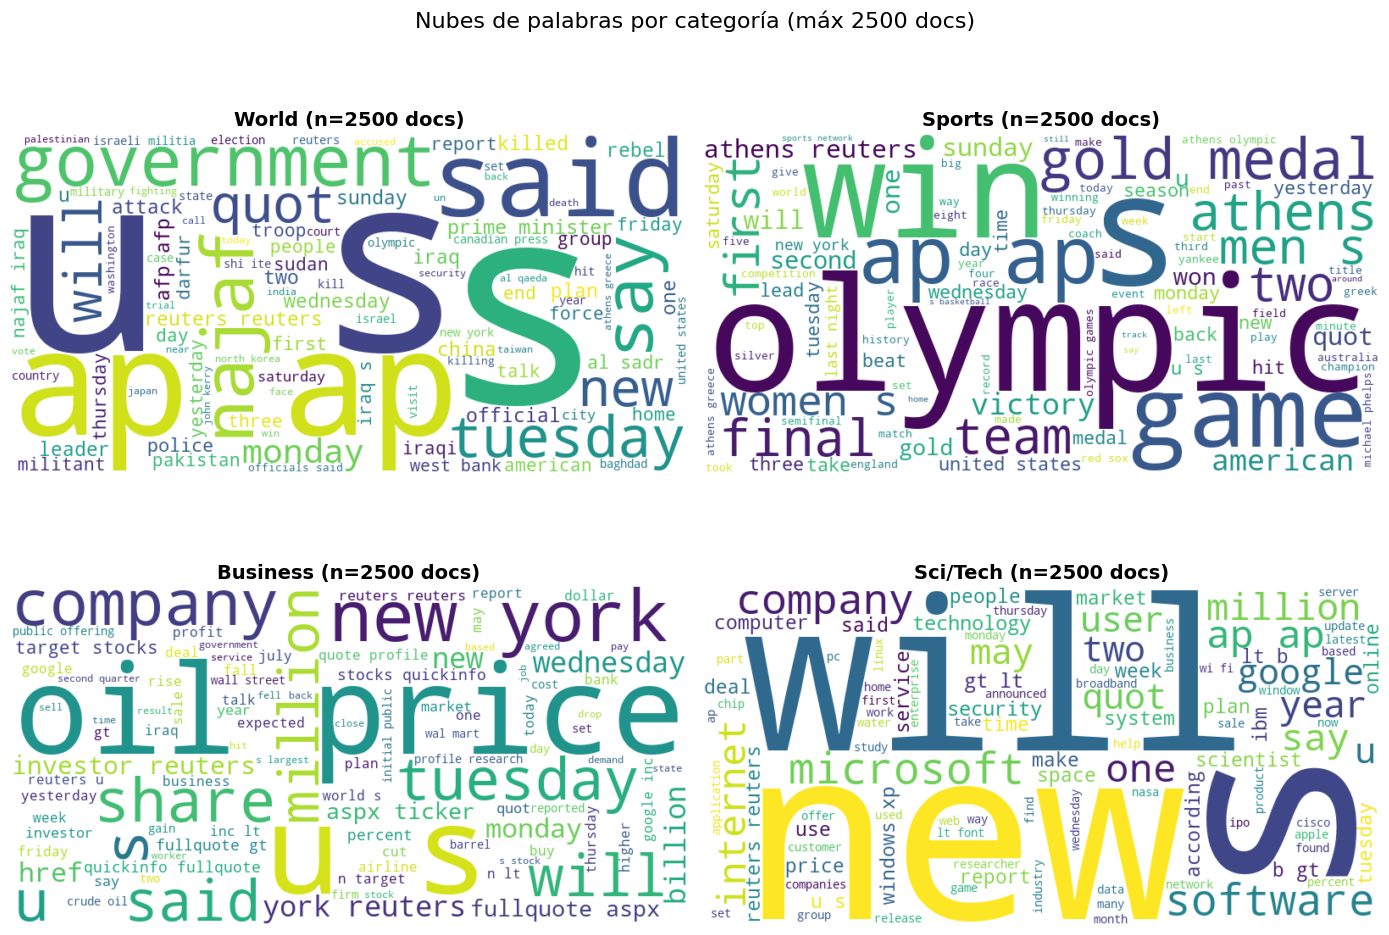

In [105]:
## Nube de palabras por categoría

# Número máximo de documentos por categoría para la nube de palabras
max_docs_per_class = 2500

# Crear figura con subplots para cada clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Para cada clase, generar nube de palabras
class_names = ds["train"].features["label"].names
for class_idx, class_name in enumerate(class_names):
    # Filtrar documentos de esta clase
    class_texts = [
        text
        for text, label in zip(ds["train"]["text"], ds["train"]["label"])
        if label == class_idx
    ]

    # Limitar a max_docs_per_class documentos
    class_texts = class_texts[:max_docs_per_class]

    # Concatenar todos los textos de la clase
    combined_text = " ".join(class_texts)

    # Tokenizar y limpiar usando nuestra función
    tokens = tokenize(combined_text)
    clean_text = " ".join(tokens)

    # Generar nube de palabras
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10,
    ).generate(clean_text)

    # Mostrar en el subplot correspondiente
    axes[class_idx].imshow(wordcloud, interpolation="bilinear")
    axes[class_idx].axis("off")
    axes[class_idx].set_title(
        f"{class_name} (n={len(class_texts)} docs)", fontsize=14, fontweight="bold"
    )

plt.tight_layout()
plt.suptitle("Nubes de palabras por categoría (máx 2500 docs)", fontsize=16, y=1.02)
plt.show()

**Comentarios:**

- Cada categoría tiene palabras muy claras que la identifican. Deportes tiene “olympic”, “game”, “medal”; Tecnología tiene “microsoft”, “software”; Negocios tiene “company”, “share”; Mundo tiene “government”, “iraq”. Esto indica que sí hay señales visibles que ayudan a diferenciarlas.

- Hay muchas palabras que no ayudan a clasificar. Términos como “said”, “reuters” o días de la semana aparecen en todas las categorías. No aportan información real sobre el tema y pueden introducir ruido.

- Negocios y Tecnología se parecen bastante. Comparten muchas palabras relacionadas con empresas y mercado. Este aspecto puede ser la causa de posibles dificultades para el modelo en terminos de diferenciar una categoria de la otra.

# Definición de la arquitectura del modelo

## Dataset Pytorch

Para empezar, definimos una clase personalizada para la creación de nuestro Dataset, la cual se hereda de `torch.utils.data.Dataset`.
Esta clase es responsable de:
- Cargar los textos y etiquetas del dataset de HuggingFace
- Tokenizar cada texto usando nuestra función `tokenize`
- Convertir tokens a IDs usando el vocabulario construido
- Aplicar truncamiento o clipping (máximo 70 tokens) y padding (completar hasta 70 tokens)
- Devolver tensores de PyTorch listos para ser procesados por el modelo

**El método `encode` toma un texto en lenguaje natural y lo transforma en una representación numérica que la red neuronal pueda procesar.**

In [41]:
max_len = 70  # decidido por el EDA (≈ P99)


class AGNewsDataset(Dataset):
    """
    Dataset personalizado para clasificación de noticias AG News.

    Esta clase adapta un dataset de Hugging Face al formato esperado por PyTorch,
    realizando preprocesamiento básico en cada ejemplo:

    - Tokenización del texto con `tokenize`.
    - Conversión de tokens a IDs con `vocab`.
    - Reemplazo de palabras desconocidas por `[UNK]`.
    - Truncamiento y padding a una longitud fija (`max_len`).

    Cada elemento devuelto contiene:
    - `input_ids`: tensor de tamaño `(max_len,)`.
    - `length`: longitud real antes de padding (acotada por `max_len`).
    - `label`: etiqueta de clase como tensor.
    """

    def __init__(self, hf_dataset, vocab, max_len=max_len):
        self.texts = hf_dataset["text"]
        self.labels = hf_dataset["label"]
        self.vocab = vocab
        self.max_len = max_len

    def _encode(self, text):
        """
        Convierte texto a lista de IDs usando el vocabulario suministrado.
        Aplica truncamiento y padding a max_len.
        """
        tokens = tokenize(text)

        # mapear tokens a ids, usando UNK si no existe
        ids = [self.vocab.get(tok, self.vocab["[UNK]"]) for tok in tokens]

        # guardar longitud real antes del padding
        length = min(len(ids), self.max_len)

        # truncar si es más largo que max_len
        ids = ids[: self.max_len]

        # padding si es más corto
        if len(ids) < self.max_len:
            ids += [self.vocab["[PAD]"]] * (self.max_len - len(ids))

        return torch.tensor(ids), length

    def __len__(
        self,
    ):  # Para conocer el tamaño del Dataset. El Dataloader lo requiere para saber batches/época, implementar Shuffle, cortar Loop correctamente
        return len(self.texts)

    def __getitem__(self, idx):  # construir y devolver un ejemplo listo para el modelo
        input_ids, length = self._encode(self.texts[idx])
        label = torch.tensor(self.labels[idx])

        return {
            "input_ids": input_ids,  # tensor (max_len,)
            "length": length,  # longitud real
            "label": label,
        }

A continuación, vamos a preparar los datos para el entrenamiento del modelo. A partir del conjunto de entrenamiento completo, crearemos una división en dos partes: una para entrenar y otra para validar el desempeño durante el proceso. Esto nos permitirá evaluar cómo generaliza el modelo a datos que no ha visto mientras aprende.

In [42]:
from torch.utils.data import random_split

# dataset completo de train HF ya envuelto en PyTorch Dataset
full_train_dataset = AGNewsDataset(ds["train"], vocab, max_len)

# dividir 90/10 para train/val (sin mezclar, con semilla fija para reproducibilidad)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(1),
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 108000
Val: 12000


## Preparación de Batches
**DataLoader, Padding y Ordenamiento por Longitud**

En esta sección definimos cómo se agrupan los ejemplos individuales en batches que el modelo de Pytorch puede procesar de forma eficiente.   

Aquí aplicamos padding dinámico para igualar las longitudes dentro del batch, construimos una máscara que distingue tokens reales de tokens de relleno y ordenamos las secuencias por longitud descendente. Este último paso es importante para trabajar correctamente con `pack_padded_sequence` en modelos recurrentes como LSTM. Finalmente, configuramos los `DataLoader` para entrenamiento, validación y prueba, asegurando mezcla solo en entrenamiento y manteniendo coherencia en el resto.

In [43]:
def collate_batch(batch):
    """
    Construye un batch a partir de una lista de ejemplos del dataset.

    Parámetros
    ----------
    batch : list[dict]
        Lista donde cada elemento tiene la estructura:
        {"input_ids": Tensor, "length": int, "label": Tensor o int}.

    Proceso
    -------
    - Apila `input_ids` para formar un tensor de forma (B, L).
    - Agrupa longitudes reales en `lengths` con forma (B,).
    - Agrupa etiquetas en `labels` con forma (B,).
    - Crea `attention_mask` (1 = token real, 0 = padding).
    - Ordena todo el batch por longitud descendente (requerido por `pack_padded_sequence`).

    Retorno
    -------
    dict
        {
            "input_ids": Tensor (B, L),
            "lengths": Tensor (B,),
            "labels": Tensor (B,),
            "attention_mask": Tensor (B, L),
        }
    """

    ## extraer items de la lista de diccionarios
    input_ids = torch.stack([item["input_ids"] for item in batch])  # (B, max_len)
    lengths = torch.tensor([item["length"] for item in batch])  # (B,)
    labels = torch.tensor([item["label"] for item in batch])  # (B,)

    ## Construir mask: 1 donde hay token real, 0 donde hay PAD
    # Esto no lo usa la LSTM directamente (a diferencia de transformers),
    # pero es muy útil para:
    # - debugging (ver cuánto padding hay)
    # - hacer pooling enmascarado
    max_len_local = input_ids.size(1)
    attention_mask = torch.arange(max_len_local)[None, :] < lengths[:, None]
    attention_mask = attention_mask.to(torch.long)  # (B, L)

    ## Pack_padded_sequence
    # Ordenar el batch por longitud descendente
    lengths_sorted, sort_idx = lengths.sort(descending=True)
    input_ids_sorted = input_ids[sort_idx]
    labels_sorted = labels[sort_idx]
    attention_mask_sorted = attention_mask[sort_idx]

    return {
        "input_ids": input_ids_sorted,
        "lengths": lengths_sorted,
        "labels": labels_sorted,
        "attention_mask": attention_mask_sorted,
    }


## Definimos los dataloaders para train, val y test usando el collate_batch para procesar cada batch

# Tamaño inicial de los batches
batch_size = 64

# TRAIN loader (shuffle=True porque entrena)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=0,
)

# VALIDATION loader (NO shuffle)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0,
)

# TEST loader
test_dataset = AGNewsDataset(ds["test"], vocab)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0,
)

In [61]:
# Verificamos que el dataloader funciona correctamente y entendemos la forma de los tensores que produce

batch = next(iter(train_loader))

print("input_ids:", batch["input_ids"].shape)
print("lengths (real):", batch["lengths"].shape, batch["lengths"][:10])
print("labels:", batch["labels"].shape, batch["labels"][:10])
print("attention_mask:", batch["attention_mask"].shape)

# % padding aproximado en el batch
total_tokens = batch["input_ids"].numel()
real_tokens = batch["attention_mask"].sum().item()
pad_tokens = total_tokens - real_tokens
print(
    f"Tokens reales: {real_tokens} | PAD: {pad_tokens} | %PAD: {pad_tokens/total_tokens:.2%}"
)

input_ids: torch.Size([64, 70])
lengths (real): torch.Size([64]) tensor([70, 70, 70, 54, 54, 52, 51, 51, 50, 49])
labels: torch.Size([64]) tensor([1, 3, 2, 0, 2, 1, 3, 3, 0, 3])
attention_mask: torch.Size([64, 70])
Tokens reales: 2458 | PAD: 2022 | %PAD: 45.13%


## Modelo LSTM para clasificación 
**Embedding -> LSTM -> Capa Final**

A continuación, definimos la clase del modelo que usaremos para clasificar noticias. El flujo es: 
- Primero convertimos los IDs de palabras en vectores con una capa de embeddings
- luego una LSTM procesa la secuencia para capturar contexto 
- Tomamos una representación del texto para pasarla por una capa lineal que produce la predicción de clase.

Para evitar que el modelo “aprenda” de los tokens de relleno, empacamos las secuencias con sus longitudes reales, de modo que la LSTM ignore el padding. La salida final son logits.

In [63]:
class LSTMTextClassifier(nn.Module):
    """
    Clasificador de texto multiclase basado en LSTM.

    Arquitectura:
    Embedding -> LSTM -> estado oculto final -> Dropout -> Linear -> logits

    Descripción:
    - Convierte IDs de tokens en vectores densos mediante una capa de embeddings.
    - Procesa la secuencia con una LSTM para capturar dependencias contextuales.
    - Usa `pack_padded_sequence` para ignorar tokens de padding durante la recurrencia.
    - Toma el estado oculto final de la última capa como representación global del texto.
    - Proyecta esa representación a `num_classes` y retorna logits (sin softmax).

    Nota:
    - La salida está diseñada para entrenar con `nn.CrossEntropyLoss`.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 1,
        dropout: float = 0.2,
        pad_idx: int = 0,
    ):
        super().__init__()

        ## Embedding: transforma IDs (enteros) -> vectores densos
        # padding_idx=pad_idx hace que el embedding del PAD no se entrene (se queda en 0 por defecto)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        ## LSTM: procesa secuencias de embeddings
        # batch_first=True => entrada/salida con shape (B, L, D)
        # dropout en LSTM SOLO aplica si num_layers > 1 (limitación de PyTorch)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        ## Dropout adicional (regularización) sobre la representación final
        self.dropout = nn.Dropout(dropout)

        ## Clasificador final (sin softmax)
        # CrossEntropyLoss aplicará internamente log-softmax
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, lengths):
        """
        input_ids: (B, L) tensor long con IDs (incluye PAD)
        lengths:   (B,) long con longitudes reales (sin PAD), ya ordenadas desc por collate_fn
        """

        ## IDs -> embeddings
        # (B, L) -> (B, L, embed_dim)
        x = self.embedding(input_ids)

        ## Empaquetar secuencias para ignorar PAD
        # lengths debe estar en CPU para pack_padded_sequence en muchos setups
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=True,  # como en collate_fn ordenamos desc, esto debe ser True
        )

        ## LSTM sobre secuencias empacadas
        # h_n: (num_layers, B, hidden_dim) = estado oculto final por capa
        # c_n: (num_layers, B, hidden_dim) = estado de celda final por capa
        packed_out, (h_n, c_n) = self.lstm(packed)

        ## Tomar el estado oculto final de la ÚLTIMA capa
        # h_n[-1]: (B, hidden_dim)
        text_repr = h_n[-1]

        ## Dropout + capa final a logits
        text_repr = self.dropout(text_repr)
        logits = self.fc(text_repr)  # (B, num_classes)

        return logits

###  Instanciar modelo + loss + optimizer 

In [64]:
# Hiperparámetros base
embed_dim = 128
hidden_dim = 128
num_layers = 1
dropout = 0.2
num_classes = 4

model = LSTMTextClassifier(
    vocab_size=len(vocab),
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=vocab["[PAD]"],
).to(device)

# Loss para multi-clase (espera logits y labels long)
criterion = nn.CrossEntropyLoss()

# Optimizer estándar
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

print(model)

LSTMTextClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


Hasta este punto, contamos con los datasets y dataloaders definidos, modelo que integra embeddings + LSTM definido e instanciado, función de perdida y optimizador definidos. Por lo tanto, ya tenemos lo necesario para realizar un entrenamiento de nuestro modelo clasificador de noticias.  

Sin embargo, antes de realizar el entrenamiento, haremos una prueba de sanidad con un batch real para verificar que el modelo y los pasos están bien definidos.

### Forward sanity check con un batch real (para entender shapes)

In [65]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)  # (B, L)
lengths = batch["lengths"].to(device)  # (B,)
labels = batch["labels"].to(device)  # (B,)

print("input_ids:", input_ids.shape, input_ids.dtype)
print("lengths:", lengths.shape, lengths.dtype)
print("labels:", labels.shape, labels.dtype)

# forward
logits = model(input_ids, lengths)
print("logits:", logits.shape, logits.dtype)  # (B, num_classes)

# loss
loss = criterion(logits, labels)
print("loss:", float(loss))

input_ids: torch.Size([64, 70]) torch.int64
lengths: torch.Size([64]) torch.int64
labels: torch.Size([64]) torch.int64
logits: torch.Size([64, 4]) torch.float32
loss: 1.3976263999938965


Notamos que la arquitectura propuesta está trabajando correctamente, como la diseñamos.   

Entra un batch de 64 documentos, donde cada elemento ya se encuentra codificado gracias a nuestro vocabulario definido, tienen un maximo de `max_len` tokens, y cada doc viene con uno de los 4 labels disponibles. Luego, al entrar dicho batch al modelo, este nos devuelve un tensor con los 4 logits de las posibles respuestas por documento.

## Entrenamiento de epocas

En esta sección definimos el ciclo de entrenamiento para una época completa. La función recorre todos los batches del DataLoader, ejecuta el paso hacia adelante (forward) para obtener las predicciones, calcula la función de pérdida y realiza el paso hacia atrás (backward) para actualizar los pesos del modelo mediante el optimizador.  

Incluimos gradient clipping para estabilizar el entrenamiento de la LSTM y evitar gradientes explosivos, un problema común en redes recurrentes. Además, acumulamos métricas básicas como la pérdida promedio y la exactitud, lo que nos permite monitorear cómo está aprendiendo el modelo en cada época.  

Con respecto a las metricas de entrenamiento definidas:
- Loss (CrossEntropyLoss): Es la señal directa de entrenamiento, mide qué tan bien está asignando probabilidad a la clase correcta.
- Accuracy: Es el "porcentaje de aciertos".

In [69]:
def train_one_epoch(model, loader, optimizer, criterion, max_norm=1.0):
    """Entrena el modelo durante una época.

    Args:
        model (nn.Module): El modelo a entrenar.
        loader (DataLoader): DataLoader con los datos de entrenamiento.
        optimizer (torch.optim.Optimizer): Optimizador para actualizar los parámetros del modelo.
        criterion (nn.Module): Función de pérdida.

    Returns:
        tuple: Pérdida promedio y exactitud para la época.
    """
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        ## reset gradientes
        optimizer.zero_grad()

        ## forward
        logits = model(input_ids, lengths)

        ## loss
        loss = criterion(logits, labels)

        ## backward
        loss.backward()

        ## gradient clipping para evitar exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)

        ## update
        optimizer.step()

        # métricas simples
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    acc = total_correct / total_examples
    return avg_loss, acc

Corremos una epoca con la función de entrenamiento como sanity check

In [70]:
# corremos una epoca de entrenamiento para verificar que todo funciona correctamente
train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")

Train loss: 0.2782 | Train acc: 0.9102


## Evaluación del modelo

Definimos la función de evaluación del modelo sobre un conjunto de datos (validación o prueba). A diferencia del entrenamiento, aquí no actualizamos pesos, solo hacemos el pase hacia adelante para medir desempeño.

In [71]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    """
    Evalúa el modelo sobre un DataLoader sin actualizar parámetros.

    Parámetros
    ----------
    model : nn.Module
        Modelo de clasificación a evaluar.
    loader : DataLoader
        DataLoader del conjunto de validación o prueba.
    criterion : nn.Module
        Función de pérdida (por ejemplo, `nn.CrossEntropyLoss`).

    Retorna
    -------
    tuple[float, float]
        `(avg_loss, acc)` donde:
        - `avg_loss` es la pérdida promedio por ejemplo.
        - `acc` es la exactitud total.
    """
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    acc = total_correct / total_examples
    return avg_loss, acc

# Ciclo de entrenamiento

En esta sección, procedemos con el entrenamiento del modelo de clasificación de noticias que hemos construido. Antes de iniciar el ciclo de épocas, es importante recordar las características principales de nuestra arquitectura.

**Componentes Clave de la Arquitectura**

- **Capa de Embeddings:**  
Transforma los IDs de palabras (números enteros) en vectores densos de 128 dimensiones. Esta capa es entrenada conjuntamente con el modelo, permitiendo que las palabras similares terminen con representaciones cercanas en el espacio vectorial. El padding de la capa es configurado para que el token especial `[PAD]` no contribuya al entrenamiento.

- **Capa LSTM:**  
La red neuronal recurrente Long Short-Term Memory procesa las secuencias de embeddings de forma secuencial. Utiliza `pack_padded_sequence` para ignorar los tokens de relleno durante la recurrencia, mejorando la eficiencia computacional y evitando que el modelo "aprenda" relaciones espurias con el padding.

- **Pooling Global:**  
En lugar de utilizar toda la secuencia, tomamos el estado oculto final de la LSTM (el último time-step válido), que funciona como una representación global del documento completo.

- **Regularización y Clasificación:**  
Aplicamos dropout (p=0.2) sobre la representación final para prevenir overfitting. Posteriormente, una capa lineal densa proyecta esta representación a 4 clases (Business, Sci/Tech, Sports, World), produciendo logits que serán procesados por `CrossEntropyLoss` durante el entrenamiento.

**Resumen de Hiperparámetros:**

- **Dimensión de embeddings:** 128
- **Dimensión oculta de LSTM:** 128
- **Número de capas LSTM:** 1
- **Dropout:** 0.2
- **Optimizador:** AdamW (lr=1e-3)
- **Función de pérdida:** CrossEntropyLoss
- **Máximo de tokens por documento:** 70
- **Tamaño de batch:** 64
- **Vocabulario:** 20,000 palabras más frecuentes (+ tokens especiales `[PAD]` y `[UNK]`)


In [72]:
import copy

# número de épocas a entrenar
num_epochs = 5

# para guardar el mejor modelo basado en val_acc
best = {"epoch": None, "val_acc": -1, "state_dict": None}

# loop de entrenamiento con evaluación al final de cada época
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # entrenar una época
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")

    # evaluar en validación
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    # checkpoint basado en val_acc
    if val_acc > best["val_acc"]:
        best["epoch"] = epoch + 1
        best["val_acc"] = val_acc
        best["state_dict"] = copy.deepcopy(model.state_dict())
        print("Nuevo mejor checkpoint")

# restaurar mejor modelo
model.load_state_dict(best["state_dict"])
print(f"\nModelo restaurado al mejor epoch: {best['epoch']}")


Epoch 1/5


Train loss: 0.2099 | Train acc: 0.9320
Val   loss: 0.2719 | Val   acc: 0.9137
Nuevo mejor checkpoint

Epoch 2/5


Train loss: 0.1630 | Train acc: 0.9464
Val   loss: 0.2705 | Val   acc: 0.9154
Nuevo mejor checkpoint

Epoch 3/5


Train loss: 0.1244 | Train acc: 0.9589
Val   loss: 0.2907 | Val   acc: 0.9153

Epoch 4/5


Train loss: 0.0944 | Train acc: 0.9684
Val   loss: 0.3134 | Val   acc: 0.9107

Epoch 5/5


Train loss: 0.0708 | Train acc: 0.9765
Val   loss: 0.3516 | Val   acc: 0.9129

Modelo restaurado al mejor epoch: 2


**Comentarios:** 

- **El modelo sí está aprendiendo.** La pérdida (Loss) de entrenamiento baja de 0.2099 a 0.0708 y la exactitud sube de 0.9320 a 0.9765. Esto indica que el optimizador está encontrando parámetros que explican cada vez mejor el conjunto de entrenamiento.

- **La mejor generalización ocurre temprano (epoch 2)**. La validación alcanza su mejor accuracy en el epoch 2 (0.9154). A partir de ahí no mejora y fluctúa levemente.

- **Se observa sobreajuste a partir del epoch 3**. Mientras la métrica de entrenamiento sigue mejorando, la pérdida de validación empieza a subir (0.2705 -> 0.2907 -> 0.3134 -> 0.3516). Eso sugiere que el modelo se está ajustando demasiado a particularidades del entrenamiento que no se transfieren a datos nuevos.

| Epoch | Train acc | Val acc    | Comentario               |
| ----- | --------- | ---------- | ------------------------ |
| 1     | 0.9320    | 0.9137     | converge rápido          |
| 2     | 0.9464    | **0.9154** | **mejor generalización** |
| 3     | 0.9589    | 0.9153     | se estanca validación    |
| 4     | 0.9684    | 0.9107     | empieza overfitting      |
| 5     | 0.9765    | 0.9129     | sobreajuste más evidente |


# Evaluación en TEST Set

Una vez completado el entrenamiento y validación del modelo, procedemos a evaluar su rendimiento en el conjunto de pruebas (test set). Esta evaluación final es crucial para confirmar que el modelo generaliza correctamente a datos completamente nuevos que no ha visto durante ninguna fase anterior del proceso (ni entrenamiento ni validación).

El conjunto de pruebas contiene 7,600 ejemplos de noticias distribuidas equitativamente entre las 4 categorías (1,900 ejemplos por clase). A continuación presentamos las métricas de desempeño global, así como un análisis detallado por clase que nos permite identificar fortalezas y debilidades del modelo en la clasificación de diferentes tipos de noticias.

In [73]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"FINAL Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

FINAL Test loss: 0.2858 | Test acc: 0.9080


A grandes rasgos, **la generalización y rendimiento en el conjunto de pruebas es consistente** con lo obtenido en el entrenamiento y validación del modelo. En validación el mejor accuracy fue ~0.9154 (epoch 2) y en test obtenemos 0.9080. La caída es pequeña (~0.7 puntos porcentuales), lo cual indica que el modelo no se esta sobreajustando al conjunto de validación de forma grave.

**Consideramos que un ~90.8% de accuracy con una LSTM relativamente simple (sin atención, sin preentrenamiento tipo Transformer) es un resultado sólido.**

##  F1 macro + matriz de confusión + reporte

F1 macro: 0.9080160147294088


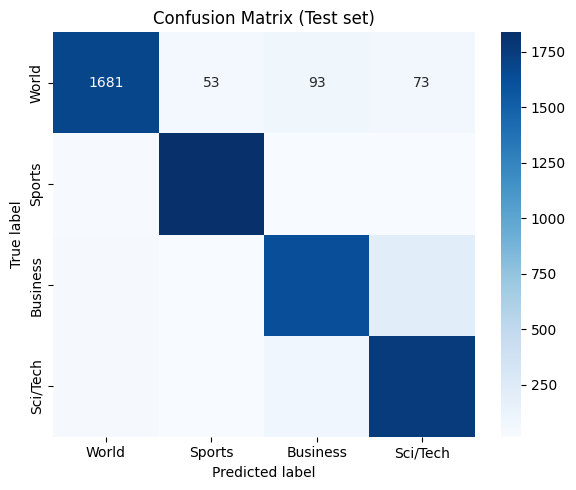

[[1681   53   93   73]
 [  27 1837   16   20]
 [  41   18 1625  216]
 [  39   19   84 1758]]

Classification report:

              precision    recall  f1-score   support

       World     0.9402    0.8847    0.9116      1900
      Sports     0.9533    0.9668    0.9600      1900
    Business     0.8938    0.8553    0.8741      1900
    Sci/Tech     0.8505    0.9253    0.8863      1900

    accuracy                         0.9080      7600
   macro avg     0.9094    0.9080    0.9080      7600
weighted avg     0.9094    0.9080    0.9080      7600



In [94]:
# Para un análisis más detallado, vamos a obtener las predicciones y etiquetas reales
# del conjunto de test para calcular métricas adicionales como F1 macro, matriz de confusión y reporte por clase.


@torch.no_grad()
def get_preds_and_labels(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Collecting preds", leave=False):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, lengths)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


test_preds, test_labels = get_preds_and_labels(model, test_loader)

# F1 macro
f1_macro = f1_score(test_labels, test_preds, average="macro")
print("F1 macro:", f1_macro)

# Matriz de confusión:

# nombres de clases
class_names = ds["train"].features["label"].names

# calcular matriz de confusión
cm = confusion_matrix(test_labels, test_preds)

# tamaño de figura
plt.figure(figsize=(6, 5))

# heatmap
sns.heatmap(
    cm,
    annot=True,  # mostrar números
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test set)")
plt.tight_layout()
plt.show()

print(cm)

# Reporte por clase
target_names = ds["train"].features["label"].names
print("\nClassification report:\n")
print(
    classification_report(test_labels, test_preds, target_names=target_names, digits=4)
)

| Clase        | Desempeño  | Interpretación                                                                                                                       | Posibles causas de error                                                                                                                           |
| ------------ | ---------- | ------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| **World**    | Alto       | Buena precisión (0.94), pero recall más bajo (0.88): identifica bien cuando predice *World*, pero deja escapar algunos casos reales. | Se confunde principalmente con *Business* (93) y *Sci/Tech* (73), probablemente por temas de economía global o tecnología internacional.           |
| **Sports**   | Muy alto   | Es la clase más sólida (F1 ≈ 0.96). Alta precisión y recall (≈0.95–0.97).                                                            | Errores mínimos; pocas confusiones con otras clases, lo que indica vocabulario muy distintivo.                                                     |
| **Business** | Medio-alto      | F1 ≈ 0.87. Recall relativamente bajo (0.86), pierde ejemplos reales.                                                                 | Se confunde con *Sci/Tech* (216 casos) y también con *World* (41), probablemente en noticias sobre empresas tecnológicas o economía internacional. |
| **Sci/Tech** | Medio-alto | Buen recall (0.93) pero precisión más baja (0.85): recupera muchos casos reales, pero comete falsos positivos.                       | Principal confusión con *Business* (84), reflejando la superposición entre tecnología y mercado empresarial.                                       |


Para finalizar, realizamos un analisis un poco mas detallado de los errores que comete nuestro modelo de clasificación.

In [101]:
# Análisis detallado de errores del modelo

## Identificar las confusiones más comunes
print("TOP CONFUSIONES MÁS COMUNES")
print("=" * 70)

confusions = []
for i in range(4):
    for j in range(4):
        if i != j:
            confusions.append((cm[i, j], class_names[i], class_names[j]))

# Ordenar por cantidad de confusiones (de mayor a menor)
confusions.sort(reverse=True)
for count, true_class, pred_class in confusions[:10]:  # mostrar top 10
    pct = (count / cm[class_names.index(true_class)].sum()) * 100
    print(
        f"\n{count:4d} casos ({pct:5.1f}%): {true_class:10s} -> predicho como {pred_class}"
    )

## Análisis de ejemplos mal clasificados
print("\nANÁLISIS DE EJEMPLOS MAL CLASIFICADOS")
print("=" * 70)

# Encontrar índices de ejemplos mal clasificados
misclassified = np.where(test_preds != test_labels)[0]
print(
    f"\nTotal de errores: {len(misclassified)}/{len(test_labels)} ({len(misclassified)/len(test_labels):.2%})"
)

# Mostrar algunos ejemplos de errores
print("\nEjemplos de errores Business → Sci/Tech (la confusión más común):")

for idx in np.random.choice(misclassified, 10, replace=False):
    print(f"\nEjemplo {idx}:")
    text_sample = ds["test"]["text"][idx]
    print(f"Texto: {text_sample[:200]}...")
    print(f"Clase real: {class_names[test_labels[idx]]}")
    print(f"Predicción: {class_names[test_preds[idx]]}")

TOP CONFUSIONES MÁS COMUNES

 216 casos ( 11.4%): Business   -> predicho como Sci/Tech

  93 casos (  4.9%): World      -> predicho como Business

  84 casos (  4.4%): Sci/Tech   -> predicho como Business

  73 casos (  3.8%): World      -> predicho como Sci/Tech

  53 casos (  2.8%): World      -> predicho como Sports

  41 casos (  2.2%): Business   -> predicho como World

  39 casos (  2.1%): Sci/Tech   -> predicho como World

  27 casos (  1.4%): Sports     -> predicho como World

  20 casos (  1.1%): Sports     -> predicho como Sci/Tech

  19 casos (  1.0%): Sci/Tech   -> predicho como Sports

ANÁLISIS DE EJEMPLOS MAL CLASIFICADOS

Total de errores: 699/7600 (9.20%)

Ejemplos de errores Business → Sci/Tech (la confusión más común):

Ejemplo 3384:
Texto: Employment Picture Expected to Improve NEW YORK - A rash of job cuts - more than 10,000 layoffs just this week from a handful of companies - has created some gloom on the jobs front. But Friday's rele...
Clase real: Sports
Predicci

**Comentarios sobre errores:**  

- **Nuevamente notamos que Sports es la clase más separable.** Presenta muy pocas confusiones relativas. Esto sugiere que el vocabulario deportivo es altamente distintivo y que el modelo captura bien esas señales léxicas específicas.

- Notamos que el modelo tiene dificultades para separar contenido económico de contenido tecnológico cuando ambos dominios comparten vocabulario (empresas tecnológicas, mercado digital, innovación industrial, etc.).

- Algunos ejemplos mal clasificados revelan **posible ruido o ambigüedad en etiquetas.** En los casos mostrados, varias noticias combinan política, economía y tecnología en el mismo texto, incluso para un humano, algunas podrían parecer complicadas de diferenciar. Esto sugiere que parte del “error” puede provenir de la naturaleza ambigua de las categorías.


**Limitación estructural del modelo:**  
La LSTM resume el texto principalmente a partir de su estado final. Esto puede hacer que enfatice las últimas partes de la secuencia o pierda matices distribuidos a lo largo del texto.

**Conclusión general:**  
El modelo generaliza bien y los errores siguen patrones temáticos comprensibles. No se observa colapso ni comportamiento arbitrario. El principal desafío no es falta de aprendizaje, sino la separación fina entre categorías semánticamente cercanas. Desde un punto de vista metodológico, el modelo cumple como baseline sólido; la mejora futura requerirá mayor capacidad contextual o representaciones más ricas del lenguaje.